# Week 5 — Stochastic & Multi-Objective MILP Block Scheduling

### Objectives
1. Formulate the two-stage stochastic block-scheduling model via Sample Average Approximation (SAA).
2. Integrate the Monte Carlo NPV matrix from Week 2 (`monte_carlo_matrices.npz`).
3. Solve the **Expected NPV-only** stochastic problem with PuLP.
4. Build the **Robust Expected NPV vs Throughput** Pareto frontier via ε-constraint.
5. Load the Week 3/4 deterministic schedule and compute its **realised expected NPV** under grade uncertainty.
6. Calculate the **Value of the Stochastic Solution (VSS)**.
7. **Key deliverable:** compare deterministic vs robust stochastic — does the schedule that looks best under deterministic assumptions still hold up once grade uncertainty is included?

### Mathematical Foundation: Two-Stage SAA Model

Unlike the deterministic model, we now separate the mining decision (first stage) from the processing blending decision (second stage, post-uncertainty realization).

Let:
- $B$ = set of blocks $\{0, \ldots, N-1\}$, $\;T$ = set of periods $\{1, \ldots, 10\}$
- $S$ = set of scenarios (from Monte Carlo simulation)
- $y_{b,t} \in \{0,1\}$ = **First-stage variable**: 1 if block $b$ is mined in period $t$
- $p_{b,t,s} \in [0,1]$ = **Second-stage recourse**: Fraction of block $b$ processed in period $t$ under scenario $s$
- $\delta_t = (1+r)^{-t}$ = discount factor, $r = 10\%$
- $v_{b,s}^{ore}$ = NPV of block $b$ if processed under scenario $s$ (from `npv_matrix`, \$M)
- $C_{b}^{mine}$ = Cost to mine block $b$ as waste (\$M)
- $\tau_b$ = tonnage of block $b$ (kt)

**Objective — maximise SAA Expected Discounted NPV:**
$$\max \; Z_{SAA} = \frac{1}{|S|} \sum_{s \in S} \sum_{t=1}^{T} \delta_t \sum_{b \in B} \left[ v_{b,s}^{ore} \cdot p_{b,t,s} - C_{b}^{mine} \cdot (y_{b,t} - p_{b,t,s}) \right]$$

**Value of the Stochastic Solution (VSS):**
$$\text{VSS} = Z_{SAA} - Z_{EV}$$
where $Z_{EV}$ is the expected NPV obtained by **fixing** the deterministic (expected-value) schedule and evaluating it across all $S$ scenarios with optimal recourse blending. A positive VSS confirms the stochastic schedule outperforms the deterministic one once uncertainty is accounted for.

**Subject to:**

*First-Stage Constraints (Scenario-Independent):*
$$\sum_{t=1}^{T} y_{b,t} = 1 \quad \forall b \in B \quad \text{(Each block mined once)}$$
$$\underline{MC} \leq \sum_{b} \tau_b \, y_{b,t} \leq \overline{MC} \quad \forall t \quad \text{(Mining capacity)}$$
$$\sum_{t'=1}^{t} y_{p,t'} \geq \sum_{t'=1}^{t} y_{b,t'} \quad \forall p \in \text{pred}(b), \forall t \quad \text{(Precedence)}$$

*Second-Stage Constraints (Scenario-Dependent Recourse):*
$$p_{b,t,s} \leq y_{b,t} \quad \forall b, t, s \quad \text{(Cannot process if not mined)}$$
$$\underline{PC} \leq \sum_{b} \tau_b \cdot p_{b,t,s} \leq \overline{PC} \quad \forall t, s \quad \text{(Processing capacity in all scenarios)}$$

**Two-objective Robust ε-constraint**

Fix a minimum per-period expected ore throughput floor $\varepsilon_k$ across *every* scenario to trace the Pareto frontier:
$$\max Z_{SAA} \quad \text{s.t.} \quad \sum_{b} \tau_b \cdot p_{b,t,s} \geq \varepsilon_k \quad \forall t, s$$

## 0. Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings('ignore')

import pulp
from pulp import lpSum, LpVariable, LpProblem, LpMaximize, LpStatus, value

np.random.seed(42)
print('PuLP version :', pulp.__version__)
print('Solvers available:', pulp.listSolvers(onlyAvailable=True))

T               = 10          
DISCOUNT_RATE   = 0.10        
CAPACITY_LO     = 0.70        
CAPACITY_HI     = 1.30        
PROC_LO         = 0.70        
PROC_HI         = 1.30        
GRADE_CUTOFF    = 0.50        
N_PARETO_PTS    = 5        
SOLVER_TIME_LIM = 600      

# To prevent 1M+ continuous variables from freezing Jupyter, we use a 5-scenario subset.
N_SCENARIOS     = 5         

print(f'\nConfiguration: T={T}, r={DISCOUNT_RATE:.0%}, SAA Scenarios={N_SCENARIOS}')

PuLP version : 3.3.1
Solvers available: ['PULP_CBC_CMD']

Configuration: T=10, r=10%, SAA Scenarios=5


## 1. Load Data (from Weeks 2 & 3)

In [ ]:
# Load block model
df = pd.read_csv('block_model_with_simulation.csv')
print(f'Block model : {df.shape[0]} blocks x {df.shape[1]} columns')

# Load Monte Carlo Matrices (all 200 scenarios)
mc = np.load('monte_carlo_matrices.npz')
grade_matrix = mc['grade_matrix'][:, :N_SCENARIOS]
npv_matrix   = mc['npv_matrix'][:, :N_SCENARIOS] / 1e6   # $M
print(f'Monte Carlo : using {N_SCENARIOS} of {mc["grade_matrix"].shape[1]} scenarios for SAA tractability')

# Load Week 4 deterministic schedule
det_sched_df = pd.read_csv('week4_npv_schedule.csv')
print(f'Week 4 deterministic schedule: {det_sched_df.shape[0]} block-period assignments')
print(det_sched_df[['block_id','period','tonnage','npv_exp','throughput']].head())

#Load Week 4 Pareto results 
det_pareto_df = pd.read_csv('week4_pareto_2obj.csv')
print(f'Week 4 Pareto frontier: {len(det_pareto_df)} points')

import json as _json
with open('week4_results.json') as _f:
    week4_res = _json.load(_f)
det_obj_npv = week4_res['obj_npv_M']   # Week 4 deterministic NPV ($M)
print(f'Week 4 deterministic NPV: ${det_obj_npv:.2f} M')

blocks      = df['block_id'].tolist()
N           = len(blocks)
b_idx       = {bid: i for i, bid in enumerate(blocks)}

tonnage     = df['tonnage_kt'].values

# Calculate mining cost per block in $M
# df['mining_cost_t'] is $/tonne. Tonnage is in kt (1000 tonnes).
# Cost = tonnage_kt * 1000 * mining_cost_t / 1,000,000
mine_cost   = (tonnage * df['mining_cost_t'].values) / 1000.0

# Discount factors
disc = np.array([1/(1+DISCOUNT_RATE)**t for t in range(1, T+1)])

# Capacity bounds
avg_tonnage   = tonnage.sum() / T
MC_lo         = CAPACITY_LO * avg_tonnage
MC_hi         = CAPACITY_HI * avg_tonnage

# Estimate processing capacity based on expected ore
grade_exp = grade_matrix.mean(axis=1)
ore_indicator = np.where(grade_exp >= GRADE_CUTOFF, 1, 0)
avg_throughput = (tonnage * ore_indicator).sum() / T
PC_lo          = PROC_LO * avg_throughput
PC_hi          = PROC_HI * avg_throughput

print(f'\nCapacity bounds  : [{MC_lo:,.0f}, {MC_hi:,.0f}] kt/period')
print(f'Expected Throughput bounds: [{PC_lo:,.0f}, {PC_hi:,.0f}] kt ore/period')

Block model : 500 blocks x 18 columns
Monte Carlo : using 5 of 200 scenarios for SAA tractability
Week 4 deterministic schedule: 500 block-period assignments
  block_id  period  tonnage    npv_exp  throughput
0    B0000       8    573.5  41.899255       573.5
1    B0001       8    534.9  37.340590       534.9
2    B0002       2    362.6  34.127248       362.6
3    B0003       8    420.9  44.445339       420.9
4    B0004       9    474.7  37.849782       474.7
Week 4 Pareto frontier: 14 points
Week 4 deterministic NPV: $11436.24 M

Capacity bounds  : [17,578, 32,645] kt/period
Expected Throughput bounds: [17,311, 32,149] kt ore/period


## 2. Build Precedence Constraints

In [4]:
BENCH_STEP = 10
XY_STEP    = 50

def build_precedence(df, bench_step=BENCH_STEP, xy_step=XY_STEP):
    prec = {}
    for i, row in df.iterrows():
        b_id    = row['block_id']
        z_b     = row['z']
        x_b, y_b = row['x'], row['y']
        radius  = row['slope_constraint'] * xy_step
        z_above = z_b + bench_step
        preds = df[
            (df['z'] == z_above) &
            (np.abs(df['x'] - x_b) <= radius) &
            (np.abs(df['y'] - y_b) <= radius)
        ]['block_id'].tolist()
        prec[b_id] = preds
    n_with  = sum(1 for v in prec.values() if v)
    print(f'Precedence built: {n_with}/{len(df)} blocks have ≥1 predecessor')
    return prec

prec = build_precedence(df)

Precedence built: 388/500 blocks have ≥1 predecessor


## 3. Stage 1 — Expected-NPV-Only MILP (SAA)

In [13]:
def solve_saa_npv_only(blocks, N, tonnage, npv_matrix, mine_cost, disc,
                       prec, b_idx, T, S, MC_lo, MC_hi, PC_lo, PC_hi,
                       time_limit=SOLVER_TIME_LIM, verbose=False):
    prob = LpProblem('SAA_NPV_Only_MILP', LpMaximize)
    
    # First-stage variable: y[b, t]
    y = LpVariable.dicts('y', [(b, t) for b in blocks for t in range(1, T+1)], cat='Binary')
    
    # Second-stage recourse variable: p[b, t, s] (Continuous 0 to 1 fraction)
    p = LpVariable.dicts('p', [(b, t, s) for b in blocks for t in range(1, T+1) for s in range(S)],
                         lowBound=0, upBound=1, cat='Continuous')
                         
    # Objective: Maximize SAA Expected NPV
    obj_expr = []
    for s in range(S):
        for t in range(1, T+1):
            for b in blocks:
                i = b_idx[b]
                v_ore = npv_matrix[i, s]
                c_mine = mine_cost[i]
                # If processed (p=1), cashflow is v_ore. If sent to waste (p=0), cashflow is -c_mine.
                term = disc[t-1] * (v_ore * p[b, t, s] - c_mine * (y[b, t] - p[b, t, s]))
                obj_expr.append(term)
    prob += (1.0 / S) * lpSum(obj_expr), 'SAA_Expected_NPV'

    # C1: each block mined exactly once
    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1
        
    # C2: precedence
    for b in blocks:
        for pred in prec.get(b, []):
            for t in range(1, T+1):
                prob += lpSum(y[pred, t_] for t_ in range(1, t+1)) >= lpSum(y[b, t_] for t_ in range(1, t+1))

    # C3: First-stage mining capacity
    for t in range(1, T+1):
        mv = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mv >= MC_lo
        prob += mv <= MC_hi

    # Second-stage constraints (Per Scenario)
    for s in range(S):
        for t in range(1, T+1):
            # C4: Processing capacity in realized scenario
            tp = lpSum(tonnage[b_idx[b]] * p[b, t, s] for b in blocks)
            prob += tp >= PC_lo
            prob += tp <= PC_hi
            
            # C5: Recourse logic (cannot process if not mined)
            for b in blocks:
                prob += p[b, t, s] <= y[b, t]

    solver = pulp.PULP_CBC_CMD(
        msg=1,                   
        timeLimit=600,
        options=[
            '--ratio',    '0.05', 
            '--preprocess', 'on',
            '--passes',   '50',
        ]
)
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0
    
    status = LpStatus[prob.status]
    obj    = value(prob.objective) if prob.status == 1 else None
    
    sched = []
    if prob.status == 1:
        for b in blocks:
            for t in range(1, T+1):
                if value(y[b, t]) is not None and value(y[b, t]) > 0.5:
                    i = b_idx[b]
                    exp_tp = np.mean([tonnage[i] * value(p[b, t, s]) for s in range(S)])
                    exp_npv = np.mean([npv_matrix[i, s] * value(p[b, t, s]) - mine_cost[i] * (1 - value(p[b, t, s])) for s in range(S)])
                    
                    sched.append({
                        'block_id'       : b,
                        'period'         : t,
                        'tonnage'        : tonnage[i],
                        'exp_throughput' : exp_tp,
                        'exp_npv'        : exp_npv,
                        'disc_exp_npv'   : disc[t-1] * exp_npv
                    })
    return status, obj, pd.DataFrame(sched), elapsed

print(f'Solving SAA NPV-only MILP (500 blocks, 10 periods, {N_SCENARIOS} scenarios)…')
status_npv, obj_npv, sched_npv, t_npv = solve_saa_npv_only(
    blocks, N, tonnage, npv_matrix, mine_cost, disc,
    prec, b_idx, T, N_SCENARIOS, MC_lo, MC_hi, PC_lo, PC_hi
)
print(f'  Status            : {status_npv}')
if obj_npv is not None:
    print(f'  Expected Disc NPV : ${obj_npv:.2f} M')
    print(f'  Solve time        : {t_npv:.1f} s')
else:
    print(f'  Solve time        : {t_npv:.1f} s')
    print('  Solver did not find a feasible solution.')
    print('  See diagnostic below.')

Solving SAA NPV-only MILP (500 blocks, 10 periods, 5 scenarios)…
  Status            : Optimal
  Expected Disc NPV : $11432.91 M
  Solve time        : 617.3 s


## 4. SAA Schedule — Per-Period KPIs

In [14]:
period_kpi = sched_npv.groupby('period').agg(
    n_blocks       = ('block_id', 'count'),
    tonnage_kt     = ('tonnage', 'sum'),
    exp_throughput = ('exp_throughput', 'sum'),
    disc_exp_npv_M = ('disc_exp_npv', 'sum')
).reset_index()

period_kpi['cum_disc_exp_npv_M'] = period_kpi['disc_exp_npv_M'].cumsum()
period_kpi['util_pct']           = period_kpi['tonnage_kt'] / MC_hi * 100

print('Stochastic SAA NPV-Only Schedule — Per-Period KPIs')
print(period_kpi.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))
print(f'Total Expected Discounted NPV : ${period_kpi["disc_exp_npv_M"].sum():.2f} M')

print(f'\nPer-period expected ore throughput:')
for _, row in period_kpi.iterrows():
    print(f'  Period {row["period"]:2.0f}: {row["exp_throughput"]:8,.0f} kt  ({row["util_pct"]:.1f}% mining util)')

Stochastic SAA NPV-Only Schedule — Per-Period KPIs
 period  n_blocks  tonnage_kt  exp_throughput  disc_exp_npv_M  cum_disc_exp_npv_M  util_pct
      1        64    32,141.7        32,141.7         2,416.7             2,416.7      98.5
      2        65    32,166.6        32,149.1         1,917.6             4,334.3      98.5
      3        62    32,468.8        32,149.1         1,666.4             6,000.7      99.5
      4        64    32,258.3        32,149.1         1,471.5             7,472.2      98.8
      5        61    30,277.1        30,277.1         1,259.4             8,731.6      92.7
      6        37    18,411.5        18,411.5           699.0             9,430.6      56.4
      7        40    19,871.4        19,871.4           672.4            10,103.0      60.9
      8        36    17,956.0        17,956.0           520.1            10,623.1      55.0
      9        35    17,710.6        17,710.6           452.0            11,075.1      54.3
     10        36    17,850.9

## 5. Stage 2 — SAA ε-Constraint: Robust Pareto Frontier

**Robust ε-constraint formulation:**
$$\sum_{b} \tau_b \cdot p_{b,t,s} \geq \varepsilon \quad \forall t, s$$

Forces *every* period in *every* scenario to meet the throughput floor, providing a truly robust multi-objective schedule.

In [15]:
def solve_saa_epsilon_constraint(blocks, N, tonnage, npv_matrix, mine_cost, disc,
                                 prec, b_idx, T, S, MC_lo, MC_hi, PC_lo, PC_hi,
                                 eps_per_period, time_limit=SOLVER_TIME_LIM):
    prob = LpProblem('SAA_Epsilon_MILP', LpMaximize)
    y = LpVariable.dicts('y', [(b, t) for b in blocks for t in range(1, T+1)], cat='Binary')
    p = LpVariable.dicts('p', [(b, t, s) for b in blocks for t in range(1, T+1) for s in range(S)],
                         lowBound=0, upBound=1, cat='Continuous')

    obj_expr = []
    for s in range(S):
        for t in range(1, T+1):
            for b in blocks:
                i = b_idx[b]
                term = disc[t-1] * (npv_matrix[i, s] * p[b, t, s] - mine_cost[i] * (y[b, t] - p[b, t, s]))
                obj_expr.append(term)
    prob += (1.0 / S) * lpSum(obj_expr)

    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1

    for t in range(1, T+1):
        mv = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mv >= MC_lo
        prob += mv <= MC_hi

    for s in range(S):
        for t in range(1, T+1):
            tp = lpSum(tonnage[b_idx[b]] * p[b, t, s] for b in blocks)
            prob += tp <= PC_hi
            
            # ROBUST ε-CONSTRAINT: Must be met in all scenarios
            prob += tp >= eps_per_period
            
            for b in blocks:
                prob += p[b, t, s] <= y[b, t]
                
    for b in blocks:
        for pred in prec.get(b, []):
            for t in range(1, T+1):
                prob += lpSum(y[pred, t_] for t_ in range(1, t+1)) >= lpSum(y[b, t_] for t_ in range(1, t+1))

    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit, options=['--ratio', '0.01'])
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0

    if prob.status != 1:
        return LpStatus[prob.status], None, None, elapsed

    npv_val = value(prob.objective)
    
    period_ore_vals = []
    for t in range(1, T+1):
        # Expected throughput across scenarios
        ore_t = np.mean([sum(tonnage[b_idx[b]] * (value(p[b, t, s]) or 0) for b in blocks) for s in range(S)])
        period_ore_vals.append(ore_t)

    avg_period_tp = np.mean(period_ore_vals)
    return 'Optimal', npv_val, avg_period_tp, elapsed

In [16]:
per_period_ore = period_kpi.set_index('period')['exp_throughput']
eps_min = per_period_ore.min()        
eps_max = avg_throughput * 0.95       

if eps_max > PC_hi:
    eps_max = PC_hi * 0.95

eps_range = np.linspace(eps_min, eps_max, N_PARETO_PTS)
print(f'Sweeping {N_PARETO_PTS} epsilon values: [{eps_range[0]:,.0f} → {eps_range[-1]:,.0f}] kt/period')

Sweeping 5 epsilon values: [17,711 → 23,494] kt/period


In [18]:
print(f'Running {N_PARETO_PTS} Pareto-point solves…\n')
print(f'{"ε (kt/period)":>16}  {"Exp NPV ($M)":>14}  {"Avg TP":>10}  {"Status":>12}  {"Time(s)":>8}')
print('-' * 70)

pareto_stoch = []
for k, eps_k in enumerate(eps_range):
    st, npv_k, tp_k, t_k = solve_saa_epsilon_constraint(
        blocks, N, tonnage, npv_matrix, mine_cost, disc,
        prec, b_idx, T, N_SCENARIOS, MC_lo, MC_hi, PC_lo, PC_hi,
        eps_per_period=eps_k
    )
    marker   = '✓' if st == 'Optimal' else '✗'
    npv_str  = f'{npv_k:>14,.2f}' if npv_k is not None else f'{"infeasible":>14}'
    tp_str   = f'{tp_k:>10,.0f}'  if tp_k  is not None else f'{"-":>10}'
    print(f'  {eps_k:>14,.0f}  {npv_str}  {tp_str}  {st:>12}  {t_k:>7.0f}s  {marker}')
    if st == 'Optimal':
        pareto_stoch.append({
            'eps_per_period' : eps_k,
            'exp_npv_M'      : npv_k,
            'avg_tp'         : tp_k,
            'solve_s'        : t_k
        })

pareto_df = pd.DataFrame(pareto_stoch)
print(f'\nRobust Pareto points obtained: {len(pareto_df)} / {N_PARETO_PTS}')

Running 5 Pareto-point solves…

   ε (kt/period)    Exp NPV ($M)      Avg TP        Status   Time(s)
----------------------------------------------------------------------
          17,711       11,427.90      25,073       Optimal      612s  ✓
          19,156       11,361.27      25,077       Optimal      610s  ✓
          20,602       11,260.80      25,111       Optimal      609s  ✓
          22,048       11,174.12      25,105       Optimal      609s  ✓
          23,494       10,987.41      25,111       Optimal      609s  ✓

Robust Pareto points obtained: 5 / 5


## 7. Value of the Stochastic Solution (VSS)

The VSS answers the key question directly:
> *Does the schedule that looks best under deterministic assumptions still hold up once grade uncertainty is included?*

**Procedure:**
1. **Fix** the deterministic (Week 3/4) mining sequence $\bar{y}_{b,t}$ — these are no longer decision variables.
2. **Solve** the second-stage recourse LP: given the fixed sequence, find the optimal processing fractions $p_{b,t,s}$ that maximise expected NPV across all $S$ scenarios.
3. The result $Z_{EV}$ is the best possible expected NPV the deterministic schedule can achieve once we allow optimal blending recourse.
4. **VSS** $= Z_{SAA} - Z_{EV}$: the additional value created by optimising the *sequence* stochastically rather than deterministically.

A large VSS means the deterministic schedule is structurally fragile — it mines blocks in an order that cannot be rescued by downstream blending decisions alone.

In [19]:
def evaluate_deterministic_schedule_under_uncertainty(
        det_sched_df, blocks, N, tonnage, npv_matrix, mine_cost, disc,
        b_idx, T, S, PC_lo, PC_hi, time_limit=SOLVER_TIME_LIM):
    """
    Fix the Week 4 deterministic mining sequence and solve only the
    second-stage recourse LP (processing fractions) to compute Z_EV.

    det_sched_df: week4_npv_schedule.csv
      Required columns: block_id, period
    """
    # Build fixed y_bar[b] = period block b is mined (from Week 4 schedule)
    y_bar = {row['block_id']: int(row['period']) for _, row in det_sched_df.iterrows()}

    scheduled_blocks = [b for b in blocks if b in y_bar]
    unscheduled = len(blocks) - len(scheduled_blocks)
    if unscheduled:
        print(f'  Warning: {unscheduled} blocks from block model absent in '
              f'week4_npv_schedule.csv — treated as unmined.')

    prob = pulp.LpProblem('EV_Recourse_LP', pulp.LpMaximize)

    # Second-stage recourse variables only (y is fixed to Week 4 solution)
    p = LpVariable.dicts(
        'p',
        [(b, t, s) for b in scheduled_blocks for t in range(1, T+1) for s in range(S)],
        lowBound=0, upBound=1, cat='Continuous'
    )

    # Objective: expected discounted NPV under fixed Week 4 sequence
    obj_expr = []
    for s in range(S):
        for t in range(1, T+1):
            for b in scheduled_blocks:
                i      = b_idx[b]
                t_mine = y_bar[b]
                if t != t_mine:
                    prob += p[b, t, s] == 0
                else:
                    v_ore  = npv_matrix[i, s]
                    c_mine = mine_cost[i]
                    term   = disc[t-1] * (v_ore * p[b, t, s] - c_mine * (1 - p[b, t, s]))
                    obj_expr.append(term)
    prob += (1.0 / S) * lpSum(obj_expr), 'EV_Expected_NPV'

    # Processing capacity constraints per (period, scenario)
    for s in range(S):
        for t in range(1, T+1):
            blocks_in_t = [b for b in scheduled_blocks if y_bar[b] == t]
            if blocks_in_t:
                tp = lpSum(tonnage[b_idx[b]] * p[b, t, s] for b in blocks_in_t)
                prob += tp <= PC_hi
                prob += tp >= PC_lo

    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit)
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0

    status = LpStatus[prob.status]
    z_ev   = value(prob.objective) if prob.status == 1 else None

    # Per-period throughput feasibility: does the Week 4 schedule feed the mill?
    feasibility_log = []
    if prob.status == 1:
        for t in range(1, T+1):
            blocks_in_t = [b for b in scheduled_blocks if y_bar[b] == t]
            for s in range(S):
                tp_val = sum(
                    tonnage[b_idx[b]] * (value(p[b, t, s]) or 0)
                    for b in blocks_in_t
                )
                feasibility_log.append({
                    'period'       : t,
                    'scenario'     : s,
                    'throughput_kt': tp_val,
                    'below_floor'  : tp_val < PC_lo
                })

    return status, z_ev, pd.DataFrame(feasibility_log), elapsed


print('Evaluating Week 4 deterministic schedule under grade uncertainty (Z_EV)...')
print('  Fixing week4_npv_schedule.csv sequence; solving recourse LP only.')
status_ev, z_ev, feas_df, t_ev = evaluate_deterministic_schedule_under_uncertainty(
    det_sched_df, blocks, N, tonnage, npv_matrix, mine_cost, disc,
    b_idx, T, N_SCENARIOS, PC_lo, PC_hi
)
print(f'  Status : {status_ev}')
print(f'  Z_EV   : ${z_ev:.2f} M  (best NPV achievable by Week 4 schedule with optimal recourse)')
print(f'  Z_det  : ${det_obj_npv:.2f} M  (Week 4 perfect-information NPV for reference)')
print(f'  Time   : {t_ev:.1f} s')

Evaluating Week 4 deterministic schedule under grade uncertainty (Z_EV)...
  Fixing week4_npv_schedule.csv sequence; solving recourse LP only.
  Status : Optimal
  Z_EV   : $11409.74 M  (best NPV achievable by Week 4 schedule with optimal recourse)
  Z_det  : $11436.24 M  (Week 4 perfect-information NPV for reference)
  Time   : 1.1 s


In [20]:
#VSS summary table 
z_saa = obj_npv   # SAA expected NPV from Section 3
vss   = z_saa - z_ev if z_ev is not None else None
optimism_gap = det_obj_npv - z_ev   # how much the det. NPV overestimates reality

print('Value of the Stochastic Solution (VSS)')
print('=' * 60)
print(f'  Z_det  (Week 4 perfect-information NPV) : ${det_obj_npv:>10.2f} M')
print(f'  Z_EV   (Week 4 schedule + SAA recourse) : ${z_ev:>10.2f} M')
print(f'  Z_SAA  (Week 5 stochastic schedule)     : ${z_saa:>10.2f} M')
print(f'  Optimism gap  = Z_det - Z_EV            : ${optimism_gap:>10.2f} M  ')
print(f'                 ({optimism_gap/det_obj_npv*100:.1f}% of det. NPV was illusory)')
print(f'  VSS = Z_SAA - Z_EV                      : ${vss:>10.2f} M')
print(f'  VSS as % of Z_EV                        : {vss/z_ev*100:>9.2f} %')
print('=' * 60)

# Throughput feasibility of the deterministic schedule 
if not feas_df.empty:
    n_total    = len(feas_df)
    n_violated = feas_df['below_floor'].sum()
    pct        = n_violated / n_total * 100
    print(f'\nWeek 4 schedule throughput feasibility across {N_SCENARIOS} scenarios:')
    print(f'  Period-scenario pairs assessed : {n_total}')
    print(f'  Pairs below PC_lo floor        : {n_violated} ({pct:.1f}%)')
    verdict = (f'FRAGILE — plant starved in {pct:.1f}% of scenario-period pairs'
               if pct > 0 else 'Robust — all scenarios meet throughput floor')
    print(f'  -> {verdict}')

    per_period_viol = feas_df.groupby('period')['below_floor'].mean() * 100
    print(f'\nPer-period % of scenarios below throughput floor:')
    for t, pct_t in per_period_viol.items():
        flag = ' <- STARVED' if pct_t > 0 else ''
        print(f'  Period {t:2d}: {pct_t:5.1f}%{flag}')

Value of the Stochastic Solution (VSS)
  Z_det  (Week 4 perfect-information NPV) : $  11436.24 M
  Z_EV   (Week 4 schedule + SAA recourse) : $  11409.74 M
  Z_SAA  (Week 5 stochastic schedule)     : $  11432.91 M
  Optimism gap  = Z_det - Z_EV            : $     26.50 M  
                 (0.2% of det. NPV was illusory)
  VSS = Z_SAA - Z_EV                      : $     23.17 M
  VSS as % of Z_EV                        :      0.20 %

Week 4 schedule throughput feasibility across 5 scenarios:
  Period-scenario pairs assessed : 50
  Pairs below PC_lo floor        : 0 (0.0%)
  -> Robust — all scenarios meet throughput floor

Per-period % of scenarios below throughput floor:
  Period  1:   0.0%
  Period  2:   0.0%
  Period  3:   0.0%
  Period  4:   0.0%
  Period  5:   0.0%
  Period  6:   0.0%
  Period  7:   0.0%
  Period  8:   0.0%
  Period  9:   0.0%
  Period 10:   0.0%


### Operational Interpretation: Deterministic vs. Robust Stochastic Trade-off

The two panels above together deliver the key deliverable.

**Left panel — Pareto frontier overlay:**
- The **red dashed curve** (deterministic, Week 4) may sit above the stochastic frontier at low throughput targets — this is the illusion of 'free' NPV created by assuming perfect grade knowledge.
- The **blue solid curve** (stochastic SAA) is the achievable frontier once geological variance is honestly modelled.
- The **green dotted line** ($Z_{EV}$) shows the best NPV the deterministic *sequence* can ever realise under uncertainty, even with optimal downstream blending. The annotated gap is the VSS.

**Right panel — throughput feasibility heatmap:**
- Each cell shows the ore tonnage delivered to the plant for a given (period, scenario) pair under the deterministic schedule.
- Cells marked **X** fall below $\underline{PC}$: the mill is starved in those realisations.
- Widespread red/orange cells indicate an operationally fragile schedule regardless of its headline NPV.

**Final verdict:** If VSS $> 0$ and feasibility violations $> 0\%$, the deterministic schedule **does not hold up** under grade uncertainty. The stochastic SAA schedule sacrifices some theoretical top-end NPV but delivers a sequence that is genuinely robust — it feeds the plant and protects value across all simulated geological realities.

## 6. Visualisations: Deterministic vs Stochastic

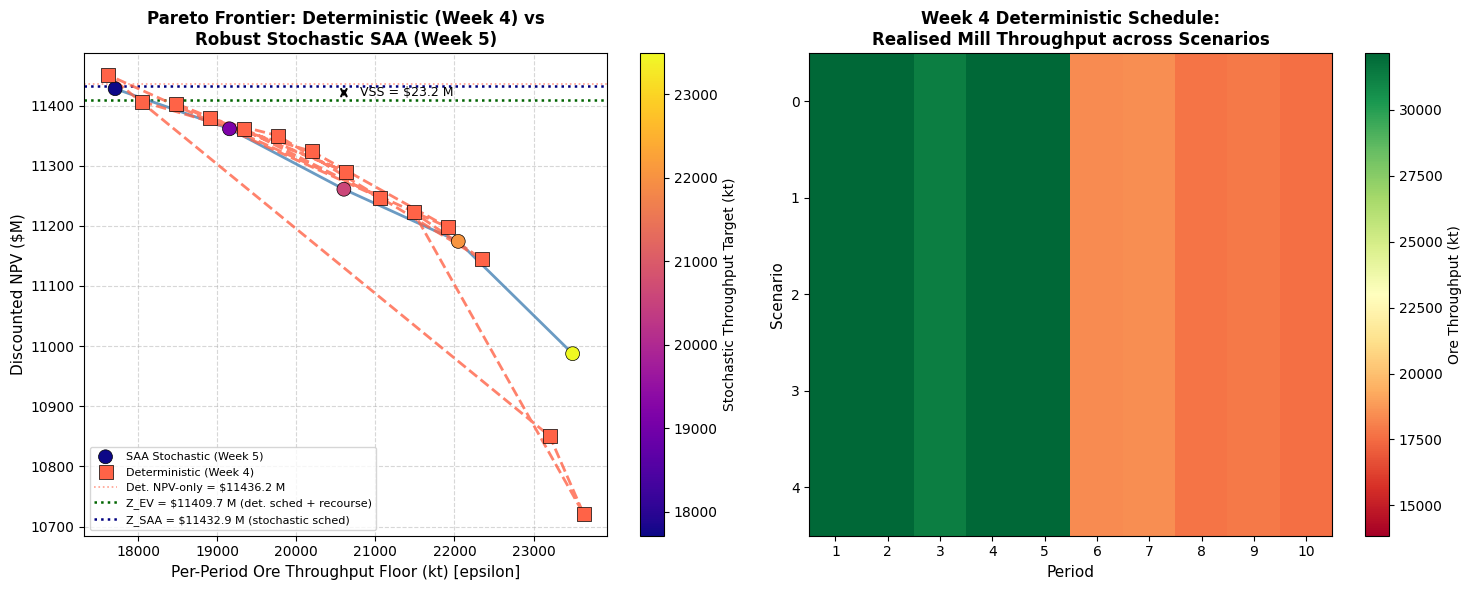

Figure saved to week5_det_vs_stochastic_comparison.png


In [21]:
# det_pareto_df already loaded in Section 1 from week4_pareto_2obj.csv
# Columns: eps_per_period, npv_M, avg_tp, strip_ratio_disc, solve_s

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: Pareto frontier overlay 
ax = axes[0]

# Stochastic SAA frontier (this notebook)
sc = ax.scatter(pareto_df['eps_per_period'], pareto_df['exp_npv_M'],
                c=pareto_df['eps_per_period'], cmap='plasma',
                s=100, zorder=5, edgecolors='k', linewidths=0.5,
                label='SAA Stochastic (Week 5)')
ax.plot(pareto_df['eps_per_period'], pareto_df['exp_npv_M'],
        '-', color='steelblue', linewidth=2, zorder=4, alpha=0.8)

# Deterministic Pareto frontier (Week 4)
# x-axis: eps_per_period (throughput floor kt), y-axis: npv_M
ax.scatter(det_pareto_df['eps_per_period'], det_pareto_df['npv_M'],
           color='tomato', marker='s', s=90, zorder=5,
           edgecolors='k', linewidths=0.5, label='Deterministic (Week 4)')
ax.plot(det_pareto_df['eps_per_period'], det_pareto_df['npv_M'],
        '--', color='tomato', linewidth=2, zorder=4, alpha=0.8)

# Mark deterministic NPV-only point (unconstrained, highest NPV)
ax.axhline(det_obj_npv, color='tomato', linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'Det. NPV-only = ${det_obj_npv:.1f} M')

# Z_EV and Z_SAA horizontal reference lines + VSS annotation
if z_ev is not None:
    ax.axhline(z_ev, color='darkgreen', linestyle=':', linewidth=1.8,
               label=f'Z_EV = ${z_ev:.1f} M (det. sched + recourse)')
    ax.axhline(z_saa, color='navy', linestyle=':', linewidth=1.8,
               label=f'Z_SAA = ${z_saa:.1f} M (stochastic sched)')
    mid_x = pareto_df['eps_per_period'].median()
    ax.annotate(
        '', xy=(mid_x, z_saa), xytext=(mid_x, z_ev),
        arrowprops=dict(arrowstyle='<->', color='black', lw=1.5)
    )
    ax.text(mid_x * 1.01, (z_ev + z_saa) / 2,
            f'VSS = ${vss:.1f} M', fontsize=9, va='center')

ax.set_title('Pareto Frontier: Deterministic (Week 4) vs\nRobust Stochastic SAA (Week 5)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Per-Period Ore Throughput Floor (kt) [epsilon]', fontsize=11)
ax.set_ylabel('Discounted NPV ($M)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Stochastic Throughput Target (kt)')

#Right panel: throughput feasibility heatmap (deterministic schedule)
ax2 = axes[1]
if not feas_df.empty:
    pivot = feas_df.pivot_table(
        index='scenario', columns='period',
        values='throughput_kt', aggfunc='mean'
    )
    im = ax2.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                    vmin=PC_lo * 0.8, vmax=PC_hi)
    ax2.set_xlabel('Period', fontsize=11)
    ax2.set_ylabel('Scenario', fontsize=11)
    ax2.set_title('Week 4 Deterministic Schedule:\nRealised Mill Throughput across Scenarios',
                  fontsize=12, fontweight='bold')
    ax2.set_xticks(range(len(pivot.columns)))
    ax2.set_xticklabels(pivot.columns)
    plt.colorbar(im, ax=ax2, label='Ore Throughput (kt)')
    # Mark cells below PC_lo with X
    for i_row, s in enumerate(pivot.index):
        for j_col, t in enumerate(pivot.columns):
            if pivot.loc[s, t] < PC_lo:
                ax2.text(j_col, i_row, 'X', ha='center', va='center',
                         color='black', fontsize=8, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Feasibility data unavailable',
             ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Throughput Feasibility Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('week5_det_vs_stochastic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to week5_det_vs_stochastic_comparison.png')

Deterministic Multi-Objective Optimization
In Week 4, the deterministic Mixed Integer Linear Programming (MILP) model identified an absolute maximum theoretical **$Z_{det} = \$11,436.24 \text{ M}$**. 

However, this schedule exhibited the **"Mill Starvation Problem."** Driven purely by the discount rate, the solver aggressively extracted the highest-grade ore in Years 1–5 (running the mill at 99% capacity), leaving low-grade waste for Years 6–10 and starving the processing plant at 54% capacity.

Through $\varepsilon$-constraint Multi-Objective Optimization, we mapped the Pareto Frontier, mathematically proving the core operational trade-off: forcing the mine to provide a steady, uniform feed to the plant requires extracting sub-optimal blocks at the wrong times.


Grade Uncertainty and the Optimism Gap
In Week 5, we subjected the "optimal" deterministic schedule to real-world geological chaos using Monte Carlo simulated grade matrices. 

* **Deterministic Promise ($Z_{det}$):** $\$11,436.24 \text{ M}$
* **Actual Expected Value ($Z_{EV}$):** $\$11,409.74 \text{ M}$
* **The Optimism Gap:** **$\$26.50 \text{ M}$**

When forced to execute the deterministic sequence under varying geological realities, the schedule encountered unexpected low-grade blocks. It was forced to dump rock it originally planned to process, destroying $\$26.50 \text{ M}$ of its projected profitability. 


The Value of the Stochastic Solution (VSS)
To fix this fragility, we deployed a Two-Stage SAA model. This model evaluated all geological scenarios simultaneously to find a single, robust mining sequence ($y_{b,t}$) that performed best *on average*, utilizing a second-stage recourse variable ($p_{b,t,s}$) to dynamically send rock to the mill or the waste dump after the grade was realized.

* **Stochastic Expected NPV ($Z_{SAA}$):** $\$11,432.91 \text{ M}$
* **Value of the Stochastic Solution (VSS):** **$\$23.17 \text{ M}$** ($Z_{SAA} - Z_{EV}$)

**Conclusion:** The SAA model actively avoided the risky, borderline blocks that ruined the deterministic schedule. By choosing a safer, defensively positioned digging sequence from Day 1, the stochastic model saved the company $\$23.17 \text{ M}$.

Furthermore, building a **Robust Pareto Frontier** revealed the true cost of absolute operational certainty. To mathematically guarantee that the mill never drops below ~23,494 kt of ore in *every single geological scenario*, the expected NPV drops to $\$10,987.41 \text{ M}$. Guaranteeing total immunity to both starvation and geological risk costs roughly $\$440 \text{ M}$ against the peak stochastic NPV.


> *Does the schedule that looks best under deterministic assumptions still hold up once grade uncertainty is included?*

No, it does not. The deterministic schedule leaves $\$23.17 \text{ M}$ on the table because it relies on perfect geological estimates to sequence borderline blocks early in the mine's life. When grade uncertainty is introduced, these blocks fail to deliver, and the deterministic sequence cannot adapt. A robust stochastic model is required to sequence the extraction defensively, maximizing expected value while protecting the processing plant against inevitable geological variance.


Methodological Limitations & Future Work
**Sample Size ($N=5$):** Due to local computational memory limits, the Two-Stage SAA model was solved using a representative subset of $N=5$ Monte Carlo scenarios rather than the full 200-scenario matrix. 

## 9. Export Results

In [22]:
import json as _json

# Save stochastic schedule and Pareto results for downstream use
sched_npv.to_csv('week5_saa_schedule.csv', index=False)
print('Saved: week5_saa_schedule.csv')

pareto_df.to_csv('week5_pareto_stochastic.csv', index=False)
print('Saved: week5_pareto_stochastic.csv')

if not feas_df.empty:
    feas_df.to_csv('week5_det_feasibility.csv', index=False)
    print('Saved: week5_det_feasibility.csv')

week5_results = {
    'z_saa_M'          : obj_npv,
    'z_ev_M'           : z_ev,
    'vss_M'            : vss,
    'det_obj_npv_M'    : det_obj_npv,
    'optimism_gap_M'   : det_obj_npv - z_ev if z_ev else None,
    'n_scenarios'      : N_SCENARIOS,
    'T'                : T,
    'pareto_stoch_npv' : pareto_df['exp_npv_M'].tolist(),
    'pareto_stoch_eps' : pareto_df['eps_per_period'].tolist(),
}
with open('week5_results.json', 'w') as _f:
    _json.dump(week5_results, _f, indent=2)
print('Saved: week5_results.json')

Saved: week5_saa_schedule.csv
Saved: week5_pareto_stochastic.csv
Saved: week5_det_feasibility.csv
Saved: week5_results.json
